In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix

from statsmodels.tsa.arima.model import ARIMA

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [34]:
customer_info = pd.read_csv("Data/customer_info.csv")
customer_orders = pd.read_csv("Data/customer_orders.csv")
customer_summary = pd.read_csv("Data/customer summary.csv")
churn = pd.read_csv("Data/churn_flag.csv")

In [35]:
df = customer_info.merge(customer_summary, on="customer_id", how="left")
df = df.merge(customer_orders, on="customer_id", how="left")
df = df.merge(churn, on="customer_id", how="left")

df.head()

,customer_id,name_x,age_x,gender_x,region_x,income_x,name_y,age_y,gender_y,region_y,...,total_spent,avg_order_value,first_order_date,last_order_date,order_id,order_amount,order_date,product_category,payment_method,is_churned_y
0,1000,Lindsey Hernandez,56.0,Male,NaN,81832.0,Lindsey Hernandez,56.0,Male,West,...,3990.0,3990.0,2023-11-05,2023-11-05,793.0,3990.0,2023-11-05,Clothing,Cash,0
1,1001,Lauren Gutierrez,69.0,Male,East,65486.0,Lauren Gutierrez,69.0,Male,East,...,14557.0,4852.0,2023-11-26,2025-07-22,33.0,1553.0,2024-02-16,Books,Cash,0
2,1001,Lauren Gutierrez,69.0,Male,East,65486.0,Lauren Gutierrez,69.0,Male,East,...,14557.0,4852.0,2023-11-26,2025-07-22,1798.0,3340.0,2025-07-22,Electronics,UPI,0
3,1001,Lauren Gutierrez,69.0,Male,East,65486.0,Lauren Gutierrez,69.0,Male,East,...,14557.0,4852.0,2023-11-26,2025-07-22,1855.0,9664.0,2023-11-26,Home,Credit Card,0
4,1002,Sharon Torres,46.0,Female,West,27209.0,Sharon Torres,46.0,Female,West,...,3335.0,1667.0,2023-10-29,2025-03-16,750.0,750.0,2025-03-16,Electronics,Credit Card,0


In [36]:
df.fillna(0, inplace=True)

# Check data
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2104 entries, 0 to 2103
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       2104 non-null   int64  
 1   name_x            2104 non-null   object 
 2   age_x             2104 non-null   float64
 3   gender_x          2104 non-null   object 
 4   region_x          2104 non-null   object 
 5   income_x          2104 non-null   float64
 6   name_y            2104 non-null   object 
 7   age_y             2104 non-null   float64
 8   gender_y          2104 non-null   object 
 9   region_y          2104 non-null   object 
 10  income_y          2104 non-null   float64
 11  is_churned_x      2104 non-null   float64
 12  total_orders      2104 non-null   float64
 13  total_spent       2104 non-null   float64
 14  avg_order_value   2104 non-null   float64
 15  first_order_date  2104 non-null   object 
 16  last_order_date   2104 non-null   object 


,customer_id,age_x,income_x,age_y,income_y,is_churned_x,total_orders,total_spent,avg_order_value,order_id,order_amount,is_churned_y
count,2104.000000,2104.000000,2104.000000,2104.000000,2104.000000,2104.000000,2104.000000,2104.000000,2104.000000,2104.000000,2104.000000,2104.000000
mean,1249.237643,40.193916,44172.783745,44.317332,49080.918230,0.180608,4.915875,14511.886882,2957.946768,993.477662,2961.528992,0.181084
std,141.395906,19.179866,20549.071467,14.203874,14422.870596,0.384785,1.884707,7055.698776,1025.037918,578.087477,2066.199581,0.385179
min,1000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1130.000000,26.750000,34111.000000,34.000000,39606.000000,0.000000,4.000000,9223.000000,2248.000000,491.750000,1436.000000,0.000000
50%,1249.500000,43.000000,46967.000000,44.293333,49573.311111,0.000000,5.000000,13608.000000,2884.000000,990.500000,2506.500000,0.000000
75%,1369.000000,55.000000,58265.500000,55.000000,58265.500000,0.000000,6.000000,18832.000000,3535.000000,1492.250000,3971.000000,0.000000
max,1499.000000,69.000000,96183.000000,69.000000,96183.000000,1.000000,9.000000,36729.000000,8844.000000,2000.000000,14352.000000,1.000000


In [37]:
print(df.columns)

Index(['customer_id', 'name_x', 'age_x', 'gender_x', 'region_x', 'income_x',
       'name_y', 'age_y', 'gender_y', 'region_y', 'income_y', 'is_churned_x',
       'total_orders', 'total_spent', 'avg_order_value', 'first_order_date',
       'last_order_date', 'order_id', 'order_amount', 'order_date',
       'product_category', 'payment_method', 'is_churned_y'],
      dtype='object')


In [38]:
# Keep only one version
df = df.drop(columns=["name_y", "age_y", "gender_y", "region_y", "income_y", "is_churned_y"])

# Rename clean columns
df = df.rename(columns={
    "name_x": "name",
    "age_x": "age",
    "gender_x": "gender",
    "region_x": "region",
    "income_x": "income",
    "is_churned_x": "churn"
})

df.head()

,customer_id,name,age,gender,region,income,churn,total_orders,total_spent,avg_order_value,first_order_date,last_order_date,order_id,order_amount,order_date,product_category,payment_method
0,1000,Lindsey Hernandez,56.0,Male,0,81832.0,0.0,1.0,3990.0,3990.0,2023-11-05,2023-11-05,793.0,3990.0,2023-11-05,Clothing,Cash
1,1001,Lauren Gutierrez,69.0,Male,East,65486.0,0.0,3.0,14557.0,4852.0,2023-11-26,2025-07-22,33.0,1553.0,2024-02-16,Books,Cash
2,1001,Lauren Gutierrez,69.0,Male,East,65486.0,0.0,3.0,14557.0,4852.0,2023-11-26,2025-07-22,1798.0,3340.0,2025-07-22,Electronics,UPI
3,1001,Lauren Gutierrez,69.0,Male,East,65486.0,0.0,3.0,14557.0,4852.0,2023-11-26,2025-07-22,1855.0,9664.0,2023-11-26,Home,Credit Card
4,1002,Sharon Torres,46.0,Female,West,27209.0,0.0,2.0,3335.0,1667.0,2023-10-29,2025-03-16,750.0,750.0,2025-03-16,Electronics,Credit Card


In [39]:
print(df.columns)

Index(['customer_id', 'name', 'age', 'gender', 'region', 'income', 'churn',
       'total_orders', 'total_spent', 'avg_order_value', 'first_order_date',
       'last_order_date', 'order_id', 'order_amount', 'order_date',
       'product_category', 'payment_method'],
      dtype='object')


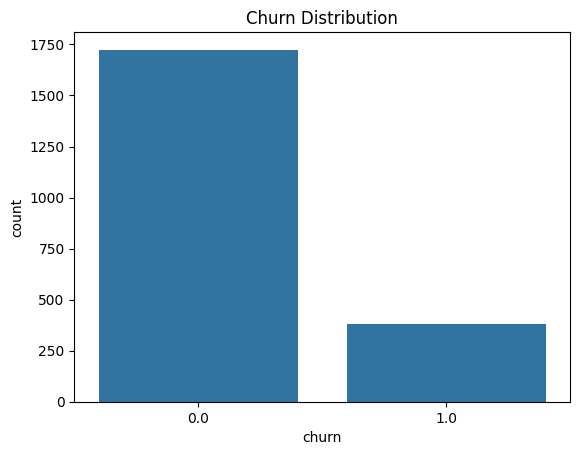

In [40]:
sns.countplot(x="churn", data=df)
plt.title("Churn Distribution")
plt.show()

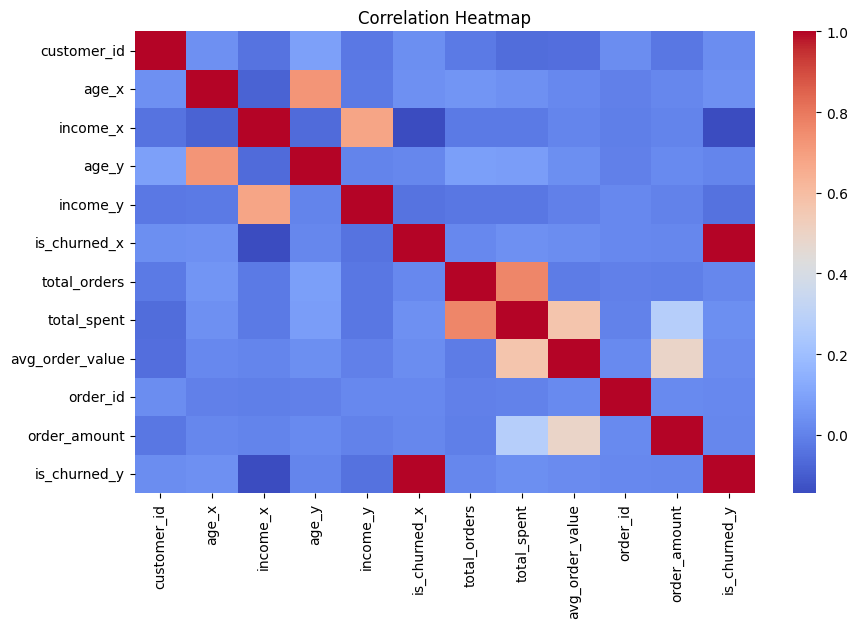

In [9]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [41]:
X = df.select_dtypes(include=["int64", "float64"]).drop("churn", axis=1)
y = df["churn"]

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [43]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression")
print("ROC-AUC:", roc_auc_score(y_test, lr_pred))
print("F1 Score:", f1_score(y_test, lr_pred))

Logistic Regression
ROC-AUC: 0.5
F1 Score: 0.0


In [44]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest")
print("ROC-AUC:", roc_auc_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))

Random Forest
ROC-AUC: 0.9127906976744187
F1 Score: 0.9044585987261147


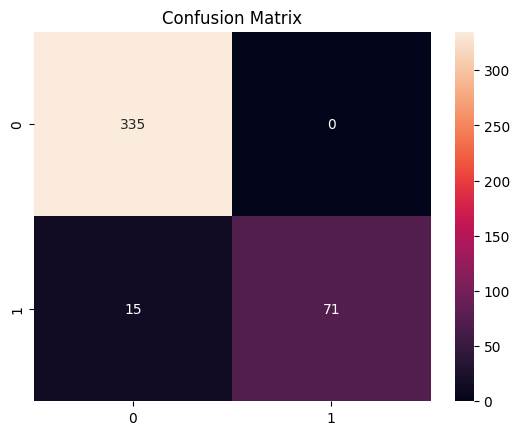

In [45]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

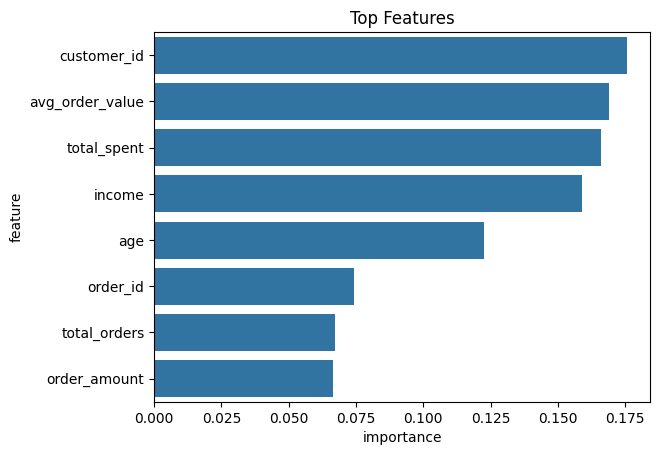

In [46]:
importance = rf.feature_importances_
features = X.columns

imp_df = pd.DataFrame({
    "feature": features,
    "importance": importance
}).sort_values(by="importance", ascending=False)

sns.barplot(x="importance", y="feature", data=imp_df.head(10))
plt.title("Top Features")
plt.show()

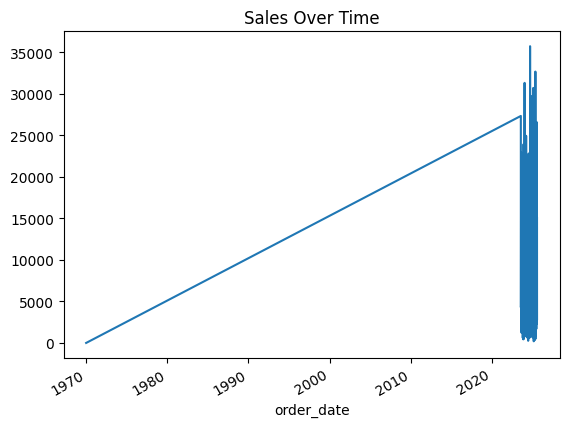

In [47]:
ts = df.groupby("order_date")["order_amount"].sum()
ts.index = pd.to_datetime(ts.index)

ts.plot(title="Sales Over Time")
plt.show()

In [48]:
model = ARIMA(ts, order=(1,1,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=5)

print("Forecast:")
print(forecast)

Forecast:
674    8838.744457
675    9205.975979
676    9228.562609
677    9229.951803
678    9230.037245
Name: predicted_mean, dtype: float64


c:\Users\prave\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\prave\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\prave\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\prave\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is ava

In [49]:
resumes = [
    "Python data scientist machine learning",
    "Java backend developer",
    "SQL data analyst"
]

job_desc = ["Looking for data scientist with machine learning"]

vectorizer = TfidfVectorizer()
tfidf = vectorizer.fit_transform(resumes + job_desc)

similarity = cosine_similarity(tfidf[-1], tfidf[:-1])

for i, score in enumerate(similarity[0]):
    print(f"Resume {i} Match Score:", score)

Resume 0 Match Score: 0.5470534039297585
Resume 1 Match Score: 0.0
Resume 2 Match Score: 0.11435668050043521


In [50]:
product_sales = df.groupby("product_category")["order_amount"].sum().reset_index()

product_sales = product_sales.sort_values(by="order_amount", ascending=False)

product_sales["cum_sum"] = product_sales["order_amount"].cumsum()
product_sales["cum_perc"] = product_sales["cum_sum"] / product_sales["order_amount"].sum()

def classify(x):
    if x <= 0.7:
        return "A"
    elif x <= 0.9:
        return "B"
    else:
        return "C"

product_sales["class"] = product_sales["cum_perc"].apply(classify)

product_sales.head()

,product_category,order_amount,cum_sum,cum_perc,class
3,Electronics,1306589.0,1306589.0,0.209690,A
2,Clothing,1278165.0,2584754.0,0.414818,A
4,Grocery,1264425.0,3849179.0,0.617741,A
1,Books,1204610.0,5053789.0,0.811064,B
5,Home,1177268.0,6231057.0,1.000000,C


In [51]:
print("Key Insights:")

print("- Random Forest performed better than Logistic Regression")
print("- High-value customers contribute most revenue (ABC Class A)")
print("- Time series shows trend/seasonality in sales")
print("- NLP model helps automate resume filtering")

Key Insights:
- Random Forest performed better than Logistic Regression
- High-value customers contribute most revenue (ABC Class A)
- Time series shows trend/seasonality in sales
- NLP model helps automate resume filtering


In [52]:
import joblib

joblib.dump(rf, "churn_model.pkl")
print("Model saved!")

Model saved!


In [53]:
df.to_csv("cleaned_data.csv", index=False)

In [54]:
X = df[[
    "age",
    "income",
    "total_orders",
    "total_spent",
    "avg_order_value"
]]

y = df["churn"]

In [55]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [56]:
import joblib
joblib.dump(model, "churn_model.pkl")

['churn_model.pkl']

In [57]:
print(X.columns)

Index(['age', 'income', 'total_orders', 'total_spent', 'avg_order_value'], dtype='object')
